# Experiment: Episode Length Effect on PPO Training

Compare training with weekly (168h) vs monthly (730h) episodes.

**Delete this notebook when done.**

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))

import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback
from battery_env_solution import BatteryStorageEnv

In [2]:
# Compare these episode lengths
EPISODE_LENGTHS = {"Week (168h)": 168, "Month (730h)": 730}
TOTAL_TIMESTEPS = int(3e6)
N_EVAL_EPISODES = 50
EVAL_INTERVAL = 10_000  # evaluate every N timesteps

for name, length in EPISODE_LENGTHS.items():
    env = BatteryStorageEnv(episode_length=length, split="all")
    print(f"{name}: {env.n_episodes} episodes, "
          f"train={BatteryStorageEnv(episode_length=length, split='train')._available_episodes}, "
          f"eval={BatteryStorageEnv(episode_length=length, split='eval')._available_episodes}")
    env.close()

Week (168h): 156 episodes, train=(0, 129), eval=(129, 156)
Month (730h): 35 episodes, train=(0, 29), eval=(29, 35)


## Training with periodic evaluation

In [3]:
class EvalCallback(BaseCallback):
    """Periodically evaluate and record mean reward."""

    def __init__(self, eval_env, eval_freq, n_eval_episodes=20):
        super().__init__()
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.timesteps = []
        self.mean_rewards = []

    def _on_step(self):
        if self.num_timesteps % self.eval_freq < self.training_env.num_envs:
            mean_r, _ = evaluate_policy(
                self.model, self.eval_env,
                n_eval_episodes=self.n_eval_episodes, deterministic=True
            )
            self.timesteps.append(self.num_timesteps)
            self.mean_rewards.append(mean_r)
        return True


results = {}

for name, length in EPISODE_LENGTHS.items():
    print(f"\n{'='*50}")
    print(f"Training: {name} (episode_length={length})")
    print(f"{'='*50}")

    train_env = make_vec_env(
        lambda: BatteryStorageEnv(episode_length=length, split="train"),
        n_envs=4,
    )
    eval_env = BatteryStorageEnv(episode_length=length, split="eval")

    # Evaluate before training
    model = PPO("MlpPolicy", train_env, verbose=0)
    mean_before, _ = evaluate_policy(model, eval_env, n_eval_episodes=N_EVAL_EPISODES)
    print(f"Before training: {mean_before:.2f} (cost: {-mean_before:.2f} €)")

    # Train with periodic eval
    cb = EvalCallback(eval_env, eval_freq=EVAL_INTERVAL, n_eval_episodes=N_EVAL_EPISODES)
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cb, progress_bar=True)

    mean_after, std_after = evaluate_policy(model, eval_env, n_eval_episodes=N_EVAL_EPISODES)
    print(f"After training:  {mean_after:.2f} ± {std_after:.2f} (cost: {-mean_after:.2f} €)")

    results[name] = {
        "timesteps": cb.timesteps,
        "rewards": cb.mean_rewards,
        "before": mean_before,
        "after": mean_after,
        "std": std_after,
        "length": length,
    }

    train_env.close()
    eval_env.close()


Training: Week (168h) (episode_length=168)


/Users/david.goll/Documents/projects/workshop-rl2-implementation/.venv/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Output()

Before training: -35.59 (cost: 35.59 €)


After training:  -25.67 ± 3.03 (cost: 25.67 €)

Training: Month (730h) (episode_length=730)


Output()

Before training: -157.16 (cost: 157.16 €)


After training:  -106.88 ± 3.58 (cost: 106.88 €)


## Compare learning curves

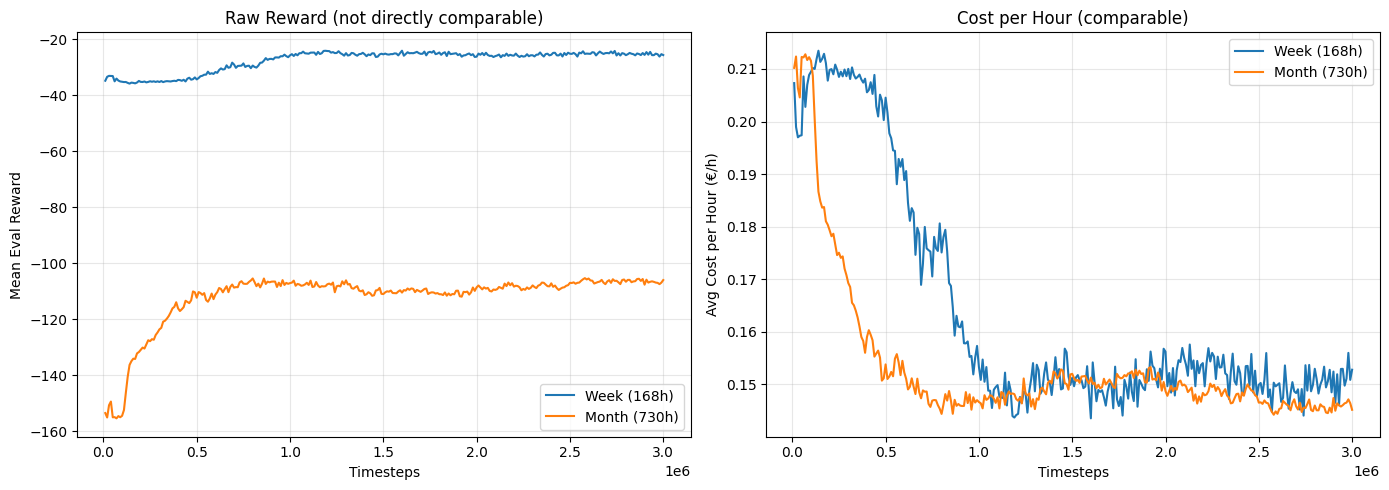

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw reward (hard to compare across episode lengths)
for name, r in results.items():
    ax1.plot(r["timesteps"], r["rewards"], label=name)
ax1.set_xlabel("Timesteps")
ax1.set_ylabel("Mean Eval Reward")
ax1.set_title("Raw Reward (not directly comparable)")
ax1.legend()
ax1.grid(alpha=0.3)

# Right: cost per hour (comparable across episode lengths)
for name, r in results.items():
    cost_per_hour = [-rw / r["length"] for rw in r["rewards"]]
    ax2.plot(r["timesteps"], cost_per_hour, label=name)
ax2.set_xlabel("Timesteps")
ax2.set_ylabel("Avg Cost per Hour (€/h)")
ax2.set_title("Cost per Hour (comparable)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
print("Final Comparison")
print("=" * 65)
print(f"{'Config':<15} {'Episodes':>10} {'Reward':>15} {'Cost/hour (€)':>15}")
print("-" * 65)
for name, r in results.items():
    n_ep = BatteryStorageEnv(episode_length=r['length'], split='eval').n_episodes
    cost_per_h = -r['after'] / r['length']
    print(f"{name:<15} {n_ep:>10} {r['after']:>11.2f} ± {r['std']:.2f} {cost_per_h:>14.4f}")

Final Comparison
Config            Episodes          Reward   Cost/hour (€)
-----------------------------------------------------------------
Week (168h)            156      -25.67 ± 3.03         0.1528
Month (730h)            35     -106.88 ± 3.58         0.1464
